<a href="https://colab.research.google.com/github/ehuangasu/MAT422/blob/main/MAT422_Section_1_3_QR_Least_Squares_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ehuangasu/MAT422/blob/main/MAT422_Section_1_3_QR_Least_Squares_Regression.ipynb)

# MAT 422 - Section 1.3: QR Decomposition, Least Squares, and Linear Regression

**Topics:** QR decomposition, least-squares problems, linear regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.3.1 QR Decomposition

QR decomposition factors a matrix A into A = Q R. The columns of Q are orthonormal, meaning their dot products form the identity matrix, and R is upper triangular. This is useful because orthonormal columns make projections and least-squares calculations cleaner.

In [11]:
A = np.array([
    [1, 1],
    [1, 2],
    [1, 3],
    [1, 4],
], dtype=float)

Q, R = np.linalg.qr(A)

print("A =")
print(A)
print("\nQ =")
print(Q)
print("\nR =")
print(R)
print("\nQ.T @ Q =")
print(Q.T @ Q)
print("\nQ @ Q.T =")
print(Q @ Q.T) # NEW
print("\nQ @ R =")
print(Q @ R)
print("Q has orthonormal columns?", np.allclose(Q.T @ Q, np.eye(Q.shape[1])))
print("Q @ R reconstructs A?", np.allclose(Q @ R, A))

A =
[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]]

Q =
[[-0.5     0.6708]
 [-0.5     0.2236]
 [-0.5    -0.2236]
 [-0.5    -0.6708]]

R =
[[-2.     -5.    ]
 [ 0.     -2.2361]]

Q.T @ Q =
[[1. 0.]
 [0. 1.]]

Q @ Q.T =
[[ 0.7  0.4  0.1 -0.2]
 [ 0.4  0.3  0.2  0.1]
 [ 0.1  0.2  0.3  0.4]
 [-0.2  0.1  0.4  0.7]]

Q @ R =
[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]]
Q has orthonormal columns? True
Q @ R reconstructs A? True


Q @ Q.T is not the identity matrix because Q is not square.

The checks above show the two main facts: Q has orthonormal columns, and multiplying Q by R reconstructs the original matrix A.

In [8]:
# NEW: R must be upper triangular

print("R is upper triangular?", np.allclose(R, np.triu(R)))
print(R)

R is upper triangular? True
[[-2.     -5.    ]
 [ 0.     -2.2361]]


## 1.3.2 Least-Squares Problems

A least-squares problem solves an overdetermined system A x approximately equals b. There may be no exact solution, so we choose x that minimizes the residual norm ||b - A x||. QR decomposition gives a stable way to solve this problem.

In [4]:
b = np.array([1.2, 1.9, 3.2, 3.9], dtype=float)

x_lstsq, residual_sum, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)
residual = b - A @ x_lstsq

print("Least-squares solution from np.linalg.lstsq:", x_lstsq)
print("residual vector b - A @ x =", residual)
print("residual norm =", np.linalg.norm(residual))
print("rank of A =", rank)
print("singular values =", singular_values)
print("normal-equation check A.T @ residual =", A.T @ residual)

Least-squares solution from np.linalg.lstsq: [0.2  0.94]
residual vector b - A @ x = [ 0.06 -0.18  0.18 -0.06]
residual norm = 0.268328157299975
rank of A = 2
singular values = [5.7794 0.7738]
normal-equation check A.T @ residual = [0. 0.]


In [5]:
# Solve the same least-squares problem using QR.
y = Q.T @ b
x_qr = np.linalg.solve(R, y)
qr_residual = b - A @ x_qr

print("Q.T @ b =", y)
print("Least-squares solution from QR:", x_qr)
print("QR residual norm =", np.linalg.norm(qr_residual))
print("QR solution matches np.linalg.lstsq?", np.allclose(x_qr, x_lstsq))

Q.T @ b = [-5.1    -2.1019]
Least-squares solution from QR: [0.2  0.94]
QR residual norm = 0.26832815729997506
QR solution matches np.linalg.lstsq? True


The normal-equation check is close to zero, which means the residual is orthogonal to the column space of A. That is the geometric meaning of the least-squares solution.

## 1.3.3 Linear Regression

Simple linear regression is a least-squares problem. For a line y = beta_0 + beta_1 x, the design matrix has one column of ones for the intercept and one column for x values. The least-squares solution gives the fitted intercept and slope.

In [9]:
x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y_data = np.array([1.1, 2.0, 2.9, 4.2, 5.1, 5.9], dtype=float)

X = np.column_stack([np.ones_like(x), x])
beta, *_ = np.linalg.lstsq(X, y_data, rcond=None)
y_pred = X @ beta
regression_residuals = y_data - y_pred
rmse = np.sqrt(np.mean(regression_residuals**2))

print("Design matrix X =")
print(X)
print("beta_0 intercept =", beta[0])
print("beta_1 slope =", beta[1])
print("predicted y =", y_pred)
print("residuals =", regression_residuals)
print("RMSE =", rmse)

# NEW
rss = regression_residuals @ regression_residuals
print("Residual sum of squares =", rss)
print("X.T @ residuals =", X.T @ regression_residuals)
print(f"Fitted line: y_hat = {beta[0]:.4f} + {beta[1]:.4f} x")

Design matrix X =
[[1. 0.]
 [1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]
beta_0 intercept = 1.061904761904761
beta_1 slope = 0.988571428571429
predicted y = [1.0619 2.0505 3.039  4.0276 5.0162 6.0048]
residuals = [ 0.0381 -0.0505 -0.139   0.1724  0.0838 -0.1048]
RMSE = 0.10881759895012307
Residual sum of squares = 0.07104761904761894
X.T @ residuals = [-0. -0.]
Fitted line: y_hat = 1.0619 + 0.9886 x


We plot the points on a line and the residuals.

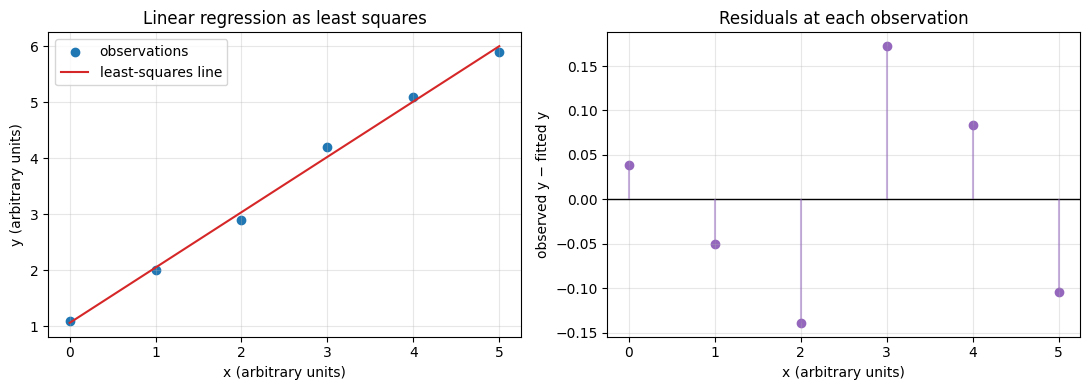

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(x, y_data, color="tab:blue", label="observations")
axes[0].plot(x, y_pred, color="tab:red", label="least-squares line")
axes[0].set(xlabel="x (arbitrary units)", ylabel="y (arbitrary units)",
            title="Linear regression as least squares")
axes[0].legend()
# NEW
axes[1].axhline(0, color="black", linewidth=1)
axes[1].vlines(x, 0, regression_residuals, color="tab:purple", alpha=0.5)
axes[1].scatter(x, regression_residuals, color="tab:purple")
axes[1].set(xlabel="x (arbitrary units)", ylabel="observed y − fitted y",
            title="Residuals at each observation")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

The slope tells us the fitted change in y for each one-unit increase in x. The intercept is the fitted value when x = 0. The RMSE summarizes the typical prediction error for this small dataset. The residuals are plotted around 0, so have zero correlation with x. So changing the parameters cannot improve the fit.

## Reflection and Rubric Checklist

- Code Accuracy and Completeness: I ran the notebook from top to bottom without errors.
- Math Concept Coverage: I demonstrated QR decomposition, least-squares problems, and linear regression.
- Examples Appropriateness: My examples show the concepts clearly and are connected to the math.
- Explanation and Documentation: I explained the purpose and meaning of each code section.
- GitHub and Colab: I saved the notebook directly from Colab to GitHub, and the `Open in Colab` badge is visible and working.
- Format and Clarity: The notebook has a logical flow, readable code, and clear section headings.
- Personalization: I changed or extended at least one example so the notebook reflects my own work.